In [1]:
!pip -q install timm umap-learn

In [3]:
from __future__ import annotations

import sys, math, gc
from pathlib import Path
from contextlib import nullcontext

from io import BytesIO
from IPython.display import display, Image as IPyImage

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import v2, InterpolationMode
from umap import UMAP

REPO_DIR = "/path/to/VECA"
CKPT_PATH = "/path/to/checkpoint.pt"
IMAGE_PATH = "/path/to/image.jpg"

RESOLUTION = 768
RESIZE_SHORT = None

BUDGETS = [8, 16, 24, 32, 48, 64]
LAYERS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

UMAP_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_SEED = 52

DTYPE = "fp32"
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
NORM_ATTN_KEY_CHUNK = 512
BUDGET_LABEL = "C"

sys.path.insert(0, REPO_DIR)

assert Path(REPO_DIR).exists(), REPO_DIR
assert Path(CKPT_PATH).exists(), CKPT_PATH
assert Path(IMAGE_PATH).exists(), IMAGE_PATH

device = torch.device(DEVICE)
print("device:", device)


device: cuda:0


In [4]:
from veca.model import VECA
from veca.config import MultiResFinetuneConfig

def display_fig_as_jpeg(fig, quality=90, dpi=150):
    buf = BytesIO()
    fig.savefig(
        buf,
        format="jpeg",
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
        pil_kwargs={"quality": quality, "optimize": True},
    )
    buf.seek(0)
    display(IPyImage(data=buf.getvalue(), format="jpeg"))
    plt.close(fig)

def clean_state_dict(state):
    out = {}
    for k, v in state.items():
        if k.startswith("module."):
            k = k[len("module."):]
        if k.startswith("student."):
            k = k[len("student."):]
        out[k] = v
    return out

def torch_load_cpu(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")

def make_cfg_from_ckpt(ckpt):
    cfg = MultiResFinetuneConfig()
    ckpt_cfg = ckpt.get("config", {}) if isinstance(ckpt, dict) else {}

    for k, v in ckpt_cfg.items():
        if hasattr(cfg, k):
            setattr(cfg, k, v)

    if "matryoshka_chunk_size" in ckpt_cfg:
        cfg.nested_chunk_size = int(ckpt_cfg["matryoshka_chunk_size"])

    cfg.model_family = "base"
    cfg.num_query_tokens = 64
    cfg.hidden_dim = 768
    cfg.num_heads = 12
    cfg.num_layers = 12
    cfg.mlp_ratio = 2.66667
    cfg.patch_size = 16
    cfg.nested_chunk_size = 8
    cfg.init_patch_from_dinov3 = False
    return cfg

def load_student(ckpt_path):
    ckpt = torch_load_cpu(ckpt_path)
    state = ckpt["student"] if isinstance(ckpt, dict) and "student" in ckpt else ckpt
    state = clean_state_dict(state)

    cfg = make_cfg_from_ckpt(ckpt if isinstance(ckpt, dict) else {})
    model = VECA(cfg)

    missing, unexpected = model.load_state_dict(state, strict=False)
    print("missing keys:", len(missing))
    print("unexpected keys:", len(unexpected))
    if missing:
        print("missing sample:", missing[:10])
    if unexpected:
        print("unexpected sample:", unexpected[:10])

    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model, cfg

student, student_cfg = load_student(CKPT_PATH)

print("Q_total:", student.Q_total)
print("chunk_size:", student.chunk_size)


missing keys: 0
unexpected keys: 0
Q_total: 64
chunk_size: 8


In [5]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def autocast_ctx(device, dtype_name):
    if device.type != "cuda" or dtype_name == "fp32":
        return nullcontext()
    if dtype_name == "bf16":
        return torch.autocast(device_type="cuda", dtype=torch.bfloat16)
    if dtype_name == "fp16":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()

def make_image_transform(resolution, resize_short=None):
    if resize_short is None:
        resize_short = int(round(resolution * 1.125))

    return v2.Compose([
        v2.ToImage(),
        v2.Resize(resize_short, interpolation=InterpolationMode.BICUBIC, antialias=True),
        v2.CenterCrop(resolution),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

def make_raw_transform(resolution, resize_short=None):
    if resize_short is None:
        resize_short = int(round(resolution * 1.125))

    return v2.Compose([
        v2.ToImage(),
        v2.Resize(resize_short, interpolation=InterpolationMode.BICUBIC, antialias=True),
        v2.CenterCrop(resolution),
        v2.ToDtype(torch.float32, scale=True),
    ])

def load_one_image(path, resolution, resize_short=None):
    with Image.open(path) as im:
        img = im.convert("RGB")

    tensor = make_image_transform(resolution, resize_short)(img).unsqueeze(0)
    raw = make_raw_transform(resolution, resize_short)(img)
    raw = raw.permute(1, 2, 0).numpy()
    raw = (raw * 255).clip(0, 255).astype(np.uint8)
    return tensor, raw

def l2_normalize(x):
    return x / np.maximum(np.linalg.norm(x, axis=-1, keepdims=True), 1e-8)

def normalize_umap_rgb(emb):
    out = np.zeros_like(emb, dtype=np.float32)
    for c in range(3):
        lo, hi = emb[:, c].min(), emb[:, c].max()
        out[:, c] = (emb[:, c] - lo) / max(hi - lo, 1e-8)
    return out

def fit_joint_umap_rgb(arrays):
    counts = [a.shape[0] for a in arrays]
    feats = np.concatenate([a.astype(np.float32) for a in arrays], axis=0)
    feats = l2_normalize(feats)

    reducer = UMAP(
        n_components=3,
        n_neighbors=UMAP_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric="cosine",
        random_state=UMAP_SEED,
    )

    rgb_all = normalize_umap_rgb(reducer.fit_transform(feats))

    out = []
    start = 0
    for count in counts:
        out.append(rgb_all[start:start + count])
        start += count
    return out

def to_uint8_rgb(x):
    x = np.asarray(x)
    if x.dtype == np.uint8:
        return x
    return (x * 255).clip(0, 255).astype(np.uint8)


In [6]:
def norm_based_attention_map(
    attn_probs,
    v,
    out_proj_weight,
    num_heads,
    head_dim,
    key_chunk=512,
):
    """
    Implements:
      T_v = V_hj W_O_h
      C_ij = sum_h alpha_hij T_v_hj
      map_ij = ||C_ij||_2
      map_i = map_i / sum_j map_ij

    Inputs:
      attn_probs: [B, H, K, N]
      v:          [B, H, N, Hd]
      weight:     [D, D] from nn.Linear out_proj
    Returns:
      norm_map:   [B, K, N]
    """
    D = out_proj_weight.shape[0]
    W_O = out_proj_weight.float().view(D, num_heads, head_dim).permute(1, 2, 0).contiguous()

    norm_chunks = []
    N_key = v.shape[2]

    for s in range(0, N_key, key_chunk):
        e = min(s + key_chunk, N_key)

        v_chunk = v[:, :, s:e, :].float()
        attn_chunk = attn_probs[:, :, :, s:e].float()

        T_v = torch.einsum("bhnd,hdc->bhnc", v_chunk, W_O)
        C_ij = torch.einsum("bhij,bhjc->bijc", attn_chunk, T_v)
        norm_chunk = torch.linalg.vector_norm(C_ij, ord=2, dim=-1)

        norm_chunks.append(norm_chunk)

        del v_chunk, attn_chunk, T_v, C_ij

    norm_map = torch.cat(norm_chunks, dim=-1)
    norm_map = norm_map / norm_map.sum(dim=-1, keepdim=True).clamp_min(1e-12)
    return norm_map

@torch.no_grad()
def extract_norm_attention_by_layer(model, images, active_k):
    B = images.shape[0]
    K = int(active_k)

    assert B == 1, "This notebook expects a single image."
    assert 1 <= K <= model.Q_total
    assert K % model.chunk_size == 0

    patches, (Hp, Wp) = model.patch_embed(images)
    queries, p_q_raw = model._build_active_query_tensors(B, K)

    p_img = model._get_patch_grid(Hp, Wp, patches.device).unsqueeze(0).expand(B, -1, -1)
    p_img = model.rope.augment_coords_patch(p_img)
    p_q = torch.tanh(p_q_raw)

    x = torch.cat([queries, patches], dim=1)
    maps_by_layer = {}

    for layer_idx, block in enumerate(model.blocks):
        if layer_idx > 0:
            q_tokens = x[:, :K, :]
            delta = model.pos_linears[layer_idx - 1](q_tokens)
            alpha = model.pos_alpha[layer_idx - 1].to(dtype=delta.dtype)
            p_q_raw = p_q_raw + alpha * delta
            p_q = torch.tanh(p_q_raw)

        coords = torch.cat([p_q, p_img], dim=1)
        cos, sin = model.rope.cos_sin(coords)

        normed = block.norm_attn(x)
        attn = block.attn

        B_, N, D = normed.shape
        H = attn.num_heads
        Hd = attn.head_dim

        q = attn.q_proj(normed).view(B_, N, H, Hd).transpose(1, 2)
        kk = attn.k_proj(normed).view(B_, N, H, Hd).transpose(1, 2)
        v = attn.v_proj(normed).view(B_, N, H, Hd).transpose(1, 2)

        q = model.rope.apply(q, cos.to(dtype=q.dtype), sin.to(dtype=q.dtype))
        kk = model.rope.apply(kk, cos.to(dtype=kk.dtype), sin.to(dtype=kk.dtype))

        logits = torch.matmul(
            q[:, :, :K, :].float(),
            kk.float().transpose(-2, -1),
        ) / math.sqrt(Hd)

        attn_probs = torch.softmax(logits, dim=-1)

        norm_map = norm_based_attention_map(
            attn_probs=attn_probs,
            v=v,
            out_proj_weight=attn.out_proj.weight,
            num_heads=H,
            head_dim=Hd,
            key_chunk=NORM_ATTN_KEY_CHUNK,
        )

        # Keep patch keys only: [B, K, K+P] -> [P, K]
        query_to_patch = norm_map[0, :, K:].transpose(0, 1)
        maps_by_layer[layer_idx + 1] = query_to_patch.cpu().numpy()

        # Advance model state using the actual block.
        x = block(x, model.rope, cos, sin, K)

        del q, kk, v, logits, attn_probs, norm_map, query_to_patch
        if device.type == "cuda":
            torch.cuda.empty_cache()

    return maps_by_layer, (Hp, Wp)


In [7]:
tensor, raw_img = load_one_image(
    IMAGE_PATH,
    resolution=RESOLUTION,
    resize_short=RESIZE_SHORT,
)
tensor = tensor.to(device)

results = {}

for k in BUDGETS:
    print(f"extracting {BUDGET_LABEL}={k}")

    with torch.inference_mode(), autocast_ctx(device, DTYPE):
        maps_by_layer, grid_hw = extract_norm_attention_by_layer(
            student,
            tensor,
            active_k=k,
        )

    selected = [maps_by_layer[layer_id] for layer_id in LAYERS]
    umap_slices = fit_joint_umap_rgb(selected)

    per_layer = {}
    h, w = grid_hw

    for layer_id, umap_rgb in zip(LAYERS, umap_slices):
        per_layer[layer_id] = to_uint8_rgb(umap_rgb.reshape(h, w, 3))

    results[k] = per_layer

    print(f"  grid={grid_hw}, layers={len(per_layer)}")

    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

print("done")


extracting C=8


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  grid=(48, 48), layers=11
extracting C=16


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  grid=(48, 48), layers=11
extracting C=24


...

  grid=(48, 48), layers=11
extracting C=48


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  grid=(48, 48), layers=11
extracting C=64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  grid=(48, 48), layers=11
done


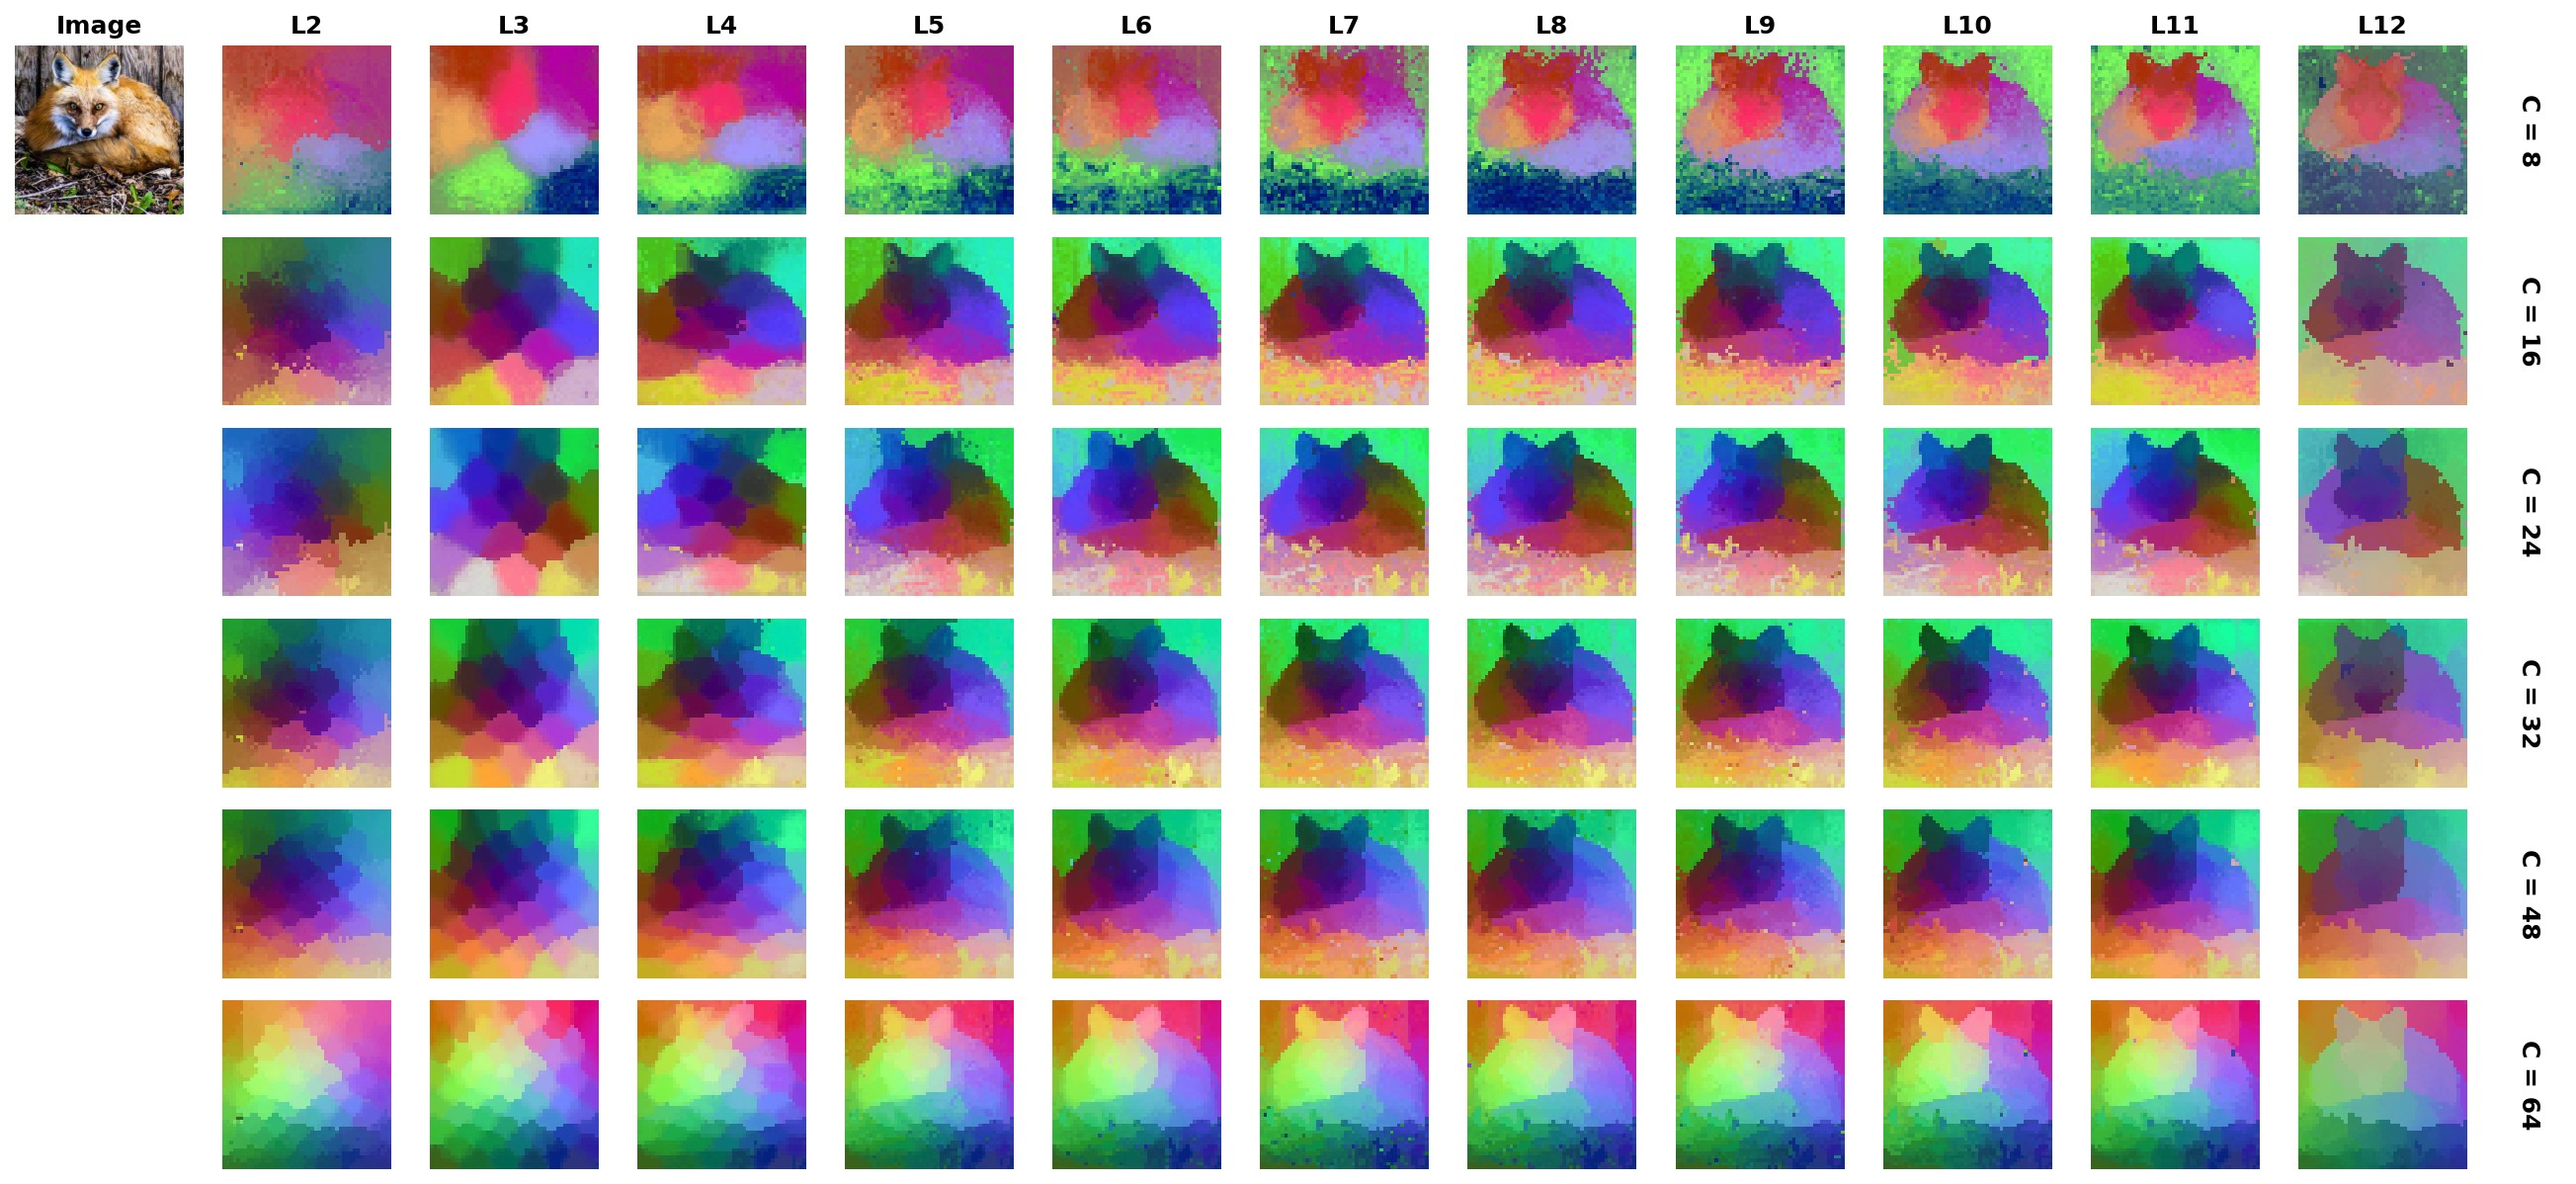

In [8]:
def show_attention_grid(raw_img, results, budgets, layers):
    rows = len(budgets)
    cols = 1 + len(layers) + 1

    width_ratios = [1.0] + [1.0] * len(layers) + [0.35]

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(1.35 * cols, 1.35 * rows),
        squeeze=False,
        gridspec_kw={"width_ratios": width_ratios},
    )

    for r, k in enumerate(budgets):
        for c in range(cols):
            axes[r, c].axis("off")

        if r == 0:
            axes[r, 0].imshow(raw_img)
            axes[r, 0].set_title("Image", fontweight="bold")
        else:
            axes[r, 0].imshow(np.ones_like(raw_img) * 255)

        for c, layer_id in enumerate(layers, start=1):
            axes[r, c].imshow(results[k][layer_id], interpolation="nearest")
            if r == 0:
                axes[r, c].set_title(f"L{layer_id}", fontweight="bold")

        axes[r, -1].text(
            0.5,
            0.5,
            f"{BUDGET_LABEL} = {k}",
            ha="center",
            va="center",
            rotation=270,
            fontsize=12,
            fontweight="bold",
            transform=axes[r, -1].transAxes,
        )

    plt.tight_layout()
    display_fig_as_jpeg(fig, quality=90, dpi=150)

show_attention_grid(raw_img, results, BUDGETS, LAYERS)
